# Task 1.4 — Temporal Split

## Agentic Risk Analyst Project

This notebook implements the temporal split for Task 1.4.

**Modeling interpretation used here**
- Development feature years: FY2011–FY2017
- Training feature years: FY2011–FY2015
- Validation feature years: FY2016–FY2017
- Final test feature years: FY2018–FY2021
- Since feature year *t* predicts outcome year *t+1*, the final test outcomes are FY2019–FY2022.

**Important:** The project materials state “Training on FY2011 through 2017, testing on FY2018 through 2022,” 
The notebook builds on the Task 1.2 modeling dataset to contain the required fields used below.


In [3]:
import pandas as pd
import numpy as np
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)


### Brief interpretation
- Imports the required libraries and prepares the notebook for analysis.


## 1. Load the Task 1.2 modeling dataset

We set `MODEL_DATA_PATH` to the Task 1.2 modeling CSV.



In [4]:
# Change this path to your Task 1.2 modeling dataset.
MODEL_DATA_PATH = "task_1_2_modeling_dataset.csv"

if "model_df" in globals():
    df = model_df.copy()
    print("Using model_df already available in the notebook.")
else:
    df = pd.read_csv("C:/Users/enock/Downloads/final_panel 1.csv")
    print(f"Loaded: {MODEL_DATA_PATH}")

print("Rows:", len(df))
print("Columns:", len(df.columns))
df.head()


Loaded: task_1_2_modeling_dataset.csv
Rows: 83726
Columns: 75


,gvkey,cik,conm,tic,cusip,fyear,datadate,INFO_DATE,costat,SIC,SIC_SOURCE,FIN,NONFIN,NEG_SALE,LNEMP,LNTA,LNSALE,LNTI,IntanTA,InvCA,CapInt,TobinQ,RET1Y,ROA,ROE,GPM,CURR_RATIO,AT_TURN,INV_TURN,DPR,PTB,PE,LNEMP_W,LNTA_W,LNSALE_W,LNTI_W,IntanTA_W,InvCA_W,CapInt_W,TobinQ_W,RET1Y_W,ROA_W,ROE_W,GPM_W,CURR_RATIO_W,AT_TURN_W,INV_TURN_W,DPR_W,PTB_W,PE_W,at,act,lct,ceq,sale,cogs,invt,intan,ppent,capx,emp,oibdp,ni,ib,dvc,epsfi,epspi,xi,csho,prcc_f,dlc,dltt,pstkl,auop,auopic
0,1004,1750.0,AAR CORP,AIR,000361105,2011,2012-05-31,2012-08-31,A,5080,firm-year,0,1,0,8.810012,7.694235,14.545230,13.304273,0.197041,0.564063,0.200033,0.581897,-0.536649,0.114220,0.079651,0.198646,2.246859,1.064014,3.003377,0.178388,0.561256,7.303030,8.810012,7.694235,14.545230,13.304273,0.197041,0.564063,0.200033,0.581897,-0.536649,0.114220,0.079651,0.198646,2.246859,1.064014,3.003377,0.178388,0.561256,7.303030,2195.653,1063.272,473.226,864.649,2074.498,1662.408,599.752,432.634,456.015,91.218,6.70,222.693,67.723,67.723,12.081,1.65,1.68,0.0,40.273,12.05,122.865,669.489,0.0,1.0,1.0
1,1004,1750.0,AAR CORP,AIR,000361105,2012,2013-05-31,2013-08-31,A,5080,firm-year,0,1,0,8.748464,7.667111,14.588901,13.275773,0.200337,0.563897,0.088180,0.701298,0.695668,0.113190,0.061685,0.208851,2.657326,1.000380,2.899416,0.216364,0.860008,14.536232,8.748464,7.667111,14.588901,13.275773,0.200337,0.563897,0.088180,0.701298,0.695668,0.113190,0.061685,0.208851,2.657326,1.000380,2.899416,0.216364,0.860008,14.536232,2136.900,1033.700,389.000,918.600,2167.100,1714.500,582.900,428.100,426.400,37.600,6.30,245.200,55.000,55.000,11.900,1.38,1.38,0.0,39.382,20.06,86.400,622.200,0.0,1.0,1.0
2,1004,1750.0,AAR CORP,AIR,000361105,2013,2014-05-31,2014-08-31,A,5080,firm-year,0,1,0,8.665786,7.695985,14.526007,13.358069,0.200091,0.566658,0.064118,0.725305,0.225160,0.118070,0.076013,0.222899,2.777667,0.938567,2.601415,0.161866,0.961789,13.278689,8.665786,7.695985,14.526007,13.358069,0.200091,0.566658,0.064118,0.725305,0.225160,0.118070,0.076013,0.222899,2.777667,0.938567,2.601415,0.161866,0.961789,13.278689,2199.500,1116.900,402.100,999.500,2035.000,1581.400,632.900,440.100,413.300,26.500,5.80,256.000,72.900,72.900,11.800,1.83,1.85,0.0,39.560,24.30,69.700,564.300,0.0,1.0,1.0
3,1004,1750.0,AAR CORP,AIR,000361105,2014,2015-05-31,2015-08-31,A,5080,firm-year,0,1,0,8.486940,7.323171,14.281946,13.247587,0.113795,0.593963,0.156949,0.792340,0.228754,0.045067,0.011059,0.157812,2.315777,0.858420,2.238580,NaN,1.238191,123.083333,8.486940,7.323171,14.281946,13.247587,0.113795,0.593963,0.156949,0.792340,0.228754,0.045067,0.011059,0.157812,2.315777,0.858420,2.238580,NaN,1.238191,123.083333,1515.000,954.100,412.000,845.100,1594.300,1342.700,566.700,172.400,295.000,46.300,4.85,83.700,10.200,-54.500,11.900,0.24,0.26,0.0,35.423,29.54,69.000,85.000,0.0,1.0,1.0
4,1004,1750.0,AAR CORP,AIR,000361105,2015,2016-05-31,2016-08-31,A,5080,firm-year,0,1,0,8.455531,7.273856,14.323894,13.242279,0.116913,0.645631,0.281618,0.686923,-0.163064,0.092591,0.055760,0.185072,2.653799,1.124480,2.397205,0.256790,0.973101,17.817518,8.455531,7.273856,14.323894,13.242279,0.116913,0.645631,0.281618,0.686923,-0.163064,0.092591,0.055760,0.185072,2.653799,1.124480,2.397205,0.256790,0.973101,17.817518,1442.100,873.100,329.000,865.800,1662.600,1354.900,563.700,168.600,313.900,88.400,4.70,136.900,47.700,40.500,10.400,1.37,1.37,0.0,34.515,24.41,12.000,136.100,0.0,1.0,1.0


### Interpretation
- Loads the Task 1.2 modeling dataset and confirms its size and structure.


## 2. t → t+1 outcome construction


In [6]:
# Keep only usable auditor outcomes
model_base = df[df["auopic"].isin([1, 2])].copy()

# Target: 1 = adverse, 0 = clean
model_base["target"] = (model_base["auopic"] == 2).astype(int)

# Feature year
model_base["feature_year"] = pd.to_numeric(
    model_base["fyear"], errors="coerce"
)

# Prediction date
model_base["prediction_date"] = pd.to_datetime(
    model_base["INFO_DATE"], errors="coerce"
)

# Create next-year outcome table
outcomes = model_base[
    ["gvkey", "feature_year", "INFO_DATE", "target"]
].copy()

outcomes = outcomes.rename(columns={
    "feature_year": "outcome_year",
    "INFO_DATE": "outcome_info_date",
    "target": "outcome_target"
})

# t -> t+1
pairs = model_base.copy()
pairs["outcome_year"] = pairs["feature_year"] + 1

pairs = pairs.merge(
    outcomes,
    on=["gvkey", "outcome_year"],
    how="inner",
    validate="one_to_one"
)

# The prediction target is the NEXT year's outcome
pairs["target"] = pairs["outcome_target"]

# Check temporal ordering
assert (pairs["prediction_date"] < pairs["outcome_info_date"]).all()

print("Modeling pairs created successfully.")
print("Rows:", len(pairs))
print("Firms:", pairs["gvkey"].nunique())
print("Feature years:", pairs["feature_year"].min(), "-", pairs["feature_year"].max())
print("Outcome years:", pairs["outcome_year"].min(), "-", pairs["outcome_year"].max())

Modeling pairs created successfully.
Rows: 36246
Firms: 5353
Feature years: 2011 - 2021
Outcome years: 2012 - 2022


## 3. Validate the Task 1.2 modeling dataset 

In [8]:

required_cols = [
    "gvkey", "feature_year", "outcome_year",
    "prediction_date", "outcome_info_date", "target"
]

# Task 1.4 must use the t -> t+1 modeling pairs
model_df = pairs.copy()

missing_cols = [c for c in required_cols if c not in model_df.columns]

if missing_cols:
    raise ValueError(
        "Missing required Task 1.4 columns: " + ", ".join(missing_cols)
    )

model_df["feature_year"] = pd.to_numeric(
    model_df["feature_year"], errors="coerce"
)

model_df["outcome_year"] = pd.to_numeric(
    model_df["outcome_year"], errors="coerce"
)

model_df["prediction_date"] = pd.to_datetime(
    model_df["prediction_date"], errors="coerce"
)

model_df["outcome_info_date"] = pd.to_datetime(
    model_df["outcome_info_date"], errors="coerce"
)

assert model_df[required_cols].notna().all().all(), \
    "Required Task 1.4 fields contain missing values."

assert (model_df["outcome_year"] == model_df["feature_year"] + 1).all(), \
    "Task 1.2 alignment failed: outcome_year must equal feature_year + 1."

print("Required-column and t -> t+1 checks passed.")
print("Rows:", len(model_df))
print("Firms:", model_df["gvkey"].nunique())


Required-column and t -> t+1 checks passed.
Rows: 36246
Firms: 5353


### Interpretation
- Confirms that all required fields are available and that each feature year correctly predicts the following outcome year.


## 4. Define Temporal Development/Validation/Test

The split is chronological. No random train/test split is used.

The timing rule requires outcomes used in an earlier partition to be available before the next partition's earliest prediction date.



In [10]:

DEV_FEATURE_START, DEV_FEATURE_END = 2011, 2017

TRAIN_FEATURE_START, TRAIN_FEATURE_END = 2011, 2015
VAL_FEATURE_START, VAL_FEATURE_END = 2016, 2017
TEST_FEATURE_START, TEST_FEATURE_END = 2018, 2021

# IMPORTANT:
# Use model_df, NOT df.
# model_df contains the t -> t+1 modeling observations.

development = model_df[
    model_df["feature_year"].between(
        DEV_FEATURE_START, DEV_FEATURE_END
    )
].copy()

train_candidates = development[
    development["feature_year"].between(
        TRAIN_FEATURE_START, TRAIN_FEATURE_END
    )
].copy()

val_candidates = development[
    development["feature_year"].between(
        VAL_FEATURE_START, VAL_FEATURE_END
    )
].copy()

test = model_df[
    model_df["feature_year"].between(
        TEST_FEATURE_START, TEST_FEATURE_END
    )
].copy()

print("Development rows:", len(development))
print("Training candidates:", len(train_candidates))
print("Validation candidates:", len(val_candidates))
print("Test rows:", len(test))

print("\nFeature-year ranges:")
print(
    "Training:",
    train_candidates["feature_year"].min(),
    "-",
    train_candidates["feature_year"].max()
)
print(
    "Validation:",
    val_candidates["feature_year"].min(),
    "-",
    val_candidates["feature_year"].max()
)
print(
    "Test:",
    test["feature_year"].min(),
    "-",
    test["feature_year"].max()
)



Development rows: 23921
Training candidates: 17457
Validation candidates: 6464
Test rows: 12325

Feature-year ranges:
Training: 2011 - 2015
Validation: 2016 - 2017
Test: 2018 - 2021


### Interpretation
- Establishes the chronological Train, Validation, and Final Test periods and applies the required information-availability timing rule.


## 5. Apply Temporal Information Date Filters


In [12]:

# Start dates for validation and test periods
val_start_date = val_candidates["prediction_date"].min()
test_start_date = test["prediction_date"].min()

# Training observations must be fully known before validation begins
train = train_candidates[
    train_candidates["outcome_info_date"] < val_start_date
].copy()

# Validation observations must be fully known before testing begins
val = val_candidates[
    val_candidates["outcome_info_date"] < test_start_date
].copy()

# Test remains untouched as the final out-of-time sample
test = test.copy()

# Sort chronologically
train = train.sort_values(
    ["prediction_date", "gvkey"]
).reset_index(drop=True)

val = val.sort_values(
    ["prediction_date", "gvkey"]
).reset_index(drop=True)

test = test.sort_values(
    ["prediction_date", "gvkey"]
).reset_index(drop=True)

print("Final temporal partitions created:")
print(f"TRAIN:      {len(train):,} observations")
print(f"VALIDATION: {len(val):,} observations")
print(f"TEST:       {len(test):,} observations")

print("\nDate ranges:")

print(
    "TRAIN:",
    train["prediction_date"].min(),
    "to",
    train["prediction_date"].max()
)

print(
    "VALIDATION:",
    val["prediction_date"].min(),
    "to",
    val["prediction_date"].max()
)

print(
    "TEST:",
    test["prediction_date"].min(),
    "to",
    test["prediction_date"].max()
)

Final temporal partitions created:
TRAIN:      14,092 observations
VALIDATION: 3,253 observations
TEST:       12,325 observations

Date ranges:
TRAIN: 2011-09-30 00:00:00 to 2015-08-31 00:00:00
VALIDATION: 2016-09-30 00:00:00 to 2017-08-31 00:00:00
TEST: 2018-09-30 00:00:00 to 2022-08-31 00:00:00


## 6. Chronology and leakage checks

In [13]:
# Leakage and chronology checks.
assert train["outcome_info_date"].max() < val["prediction_date"].min(),     "Temporal leakage detected between training and validation."
assert val["outcome_info_date"].max() < test["prediction_date"].min(),     "Temporal leakage detected between validation and test."

assert set(train["feature_year"]).isdisjoint(set(val["feature_year"]))
assert set(train["feature_year"]).isdisjoint(set(test["feature_year"]))
assert set(val["feature_year"]).isdisjoint(set(test["feature_year"]))

for name, part in [("TRAIN", train), ("VALIDATION", val), ("TEST", test)]:
    assert (part["outcome_year"] == part["feature_year"] + 1).all(),         f"{name}: t -> t+1 check failed."
    classes = set(part["target"].dropna().unique())
    assert {0, 1}.issubset(classes),         f"{name} does not contain both target classes 0 and 1. Found: {classes}"

print("All chronology, partition-disjointness, and target-class checks passed.")


All chronology, partition-disjointness, and target-class checks passed.


### Interpretation
- Confirms that the partitions are chronologically separated, feature years do not overlap, and both target classes are represented.


## 7. Verify target classes

Target convention:
- `0` = effective control
- `1` = adverse opinion



In [14]:
def partition_summary(part, name):
    return {
        "partition": name,
        "rows": len(part),
        "firms": part["gvkey"].nunique(),
        "feature_year_min": int(part["feature_year"].min()),
        "feature_year_max": int(part["feature_year"].max()),
        "outcome_year_min": int(part["outcome_year"].min()),
        "outcome_year_max": int(part["outcome_year"].max()),
        "prediction_date_min": part["prediction_date"].min(),
        "prediction_date_max": part["prediction_date"].max(),
        "adverse_count": int((part["target"] == 1).sum()),
        "adverse_rate": float(part["target"].mean()),
    }

split_summary = pd.DataFrame([
    partition_summary(train, "TRAIN"),
    partition_summary(val, "VALIDATION"),
    partition_summary(test, "TEST"),
])

display(split_summary)


,partition,rows,firms,feature_year_min,feature_year_max,outcome_year_min,outcome_year_max,prediction_date_min,prediction_date_max,adverse_count,adverse_rate
0,TRAIN,14092,4136,2011,2014,2012,2015,2011-09-30,2015-08-31,522,0.037042
1,VALIDATION,3253,3253,2016,2016,2017,2017,2016-09-30,2017-08-31,116,0.035659
2,TEST,12325,3785,2018,2021,2019,2022,2018-09-30,2022-08-31,471,0.038215


### Interpretation
- Summarizes the observations, firms, years, prediction dates, and adverse-outcome rates in each partition.


## 8. Produce the Task 1.4 split summary


In [15]:
split_decision = {
    "task": "1.4 Temporal split",
    "split_type": "chronological / temporal",
    "development_feature_years": "FY2011-FY2017",
    "training_feature_years": "FY2011-FY2015",
    "validation_feature_years": "FY2016-FY2017",
    "test_feature_years": "FY2018-FY2021",
    "training_outcome_years": f"FY{int(train['outcome_year'].min())}-FY{int(train['outcome_year'].max())}",
    "validation_outcome_years": f"FY{int(val['outcome_year'].min())}-FY{int(val['outcome_year'].max())}",
    "test_outcome_years": f"FY{int(test['outcome_year'].min())}-FY{int(test['outcome_year'].max())}",
    "timing_rule": "Earlier outcome_info_date must be before the next partition's earliest prediction_date.",
    "prediction_target_alignment": "feature year t predicts outcome year t+1",
    "test_role": "final out-of-time evaluation",
    "validation_role": "model selection / probability calibration",
    "information_date_limitation": "INFO_DATE is treated as the assumed availability date; auditor report publication date is not independently verified."
}

for k, v in split_decision.items():
    print(f"{k}: {v}")


task: 1.4 Temporal split
split_type: chronological / temporal
development_feature_years: FY2011-FY2017
training_feature_years: FY2011-FY2015
validation_feature_years: FY2016-FY2017
test_feature_years: FY2018-FY2021
training_outcome_years: FY2012-FY2015
validation_outcome_years: FY2017-FY2017
test_outcome_years: FY2019-FY2022
timing_rule: Earlier outcome_info_date must be before the next partition's earliest prediction_date.
prediction_target_alignment: feature year t predicts outcome year t+1
test_role: final out-of-time evaluation
validation_role: model selection / probability calibration
information_date_limitation: INFO_DATE is treated as the assumed availability date; auditor report publication date is not independently verified.


### Interpretation
- Records the final Task 1.4 split specification for reproducibility and downstream model documentation.


## 9. Graphic representations of the temporal split

The following visuals provide a concise presentation of the Task 1.4 design:
1. A temporal timeline showing the Train, Validation, and Final Test periods.
2. Adverse-outcome rate by partition.
3. Number of observations by partition.

These graphics use the actual partition results produced above; no values are manually entered.

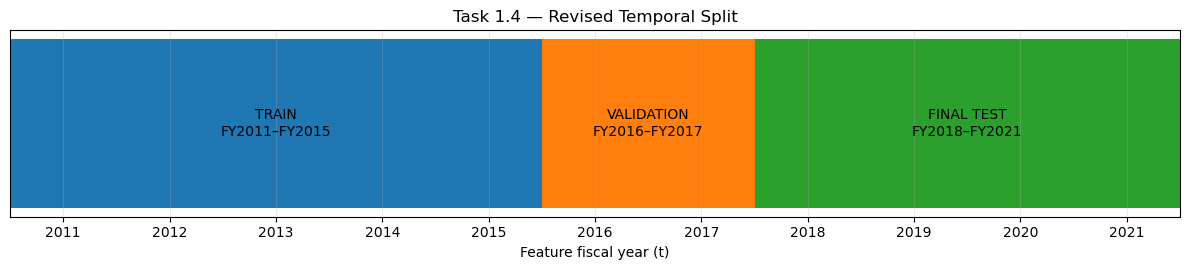

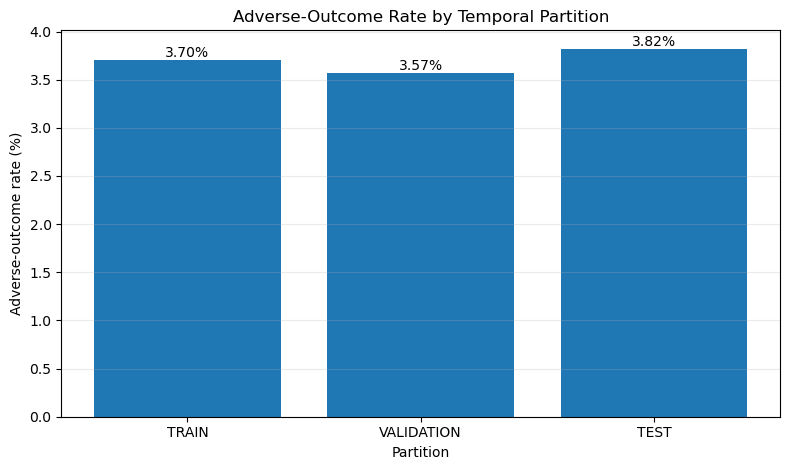

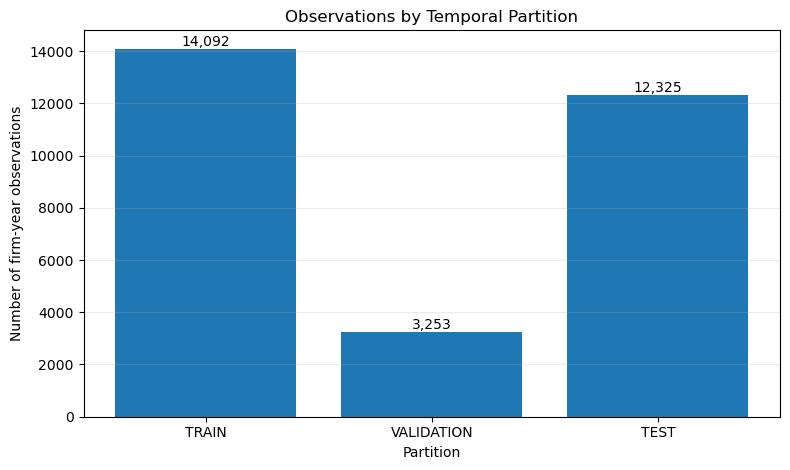

In [16]:
import matplotlib.pyplot as plt

# -----------------------------
# Graphic 1: Temporal split timeline
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 2.8))

timeline = [
    ("TRAIN", TRAIN_FEATURE_START, TRAIN_FEATURE_END, 1),
    ("VALIDATION", VAL_FEATURE_START, VAL_FEATURE_END, 1),
    ("FINAL TEST", TEST_FEATURE_START, TEST_FEATURE_END, 1),
]

for label, start, end, y in timeline:
    ax.barh(y, end - start + 1, left=start - 0.5, height=0.45, label=label)
    ax.text((start + end) / 2, y, f"{label}\nFY{start}–FY{end}",
            ha="center", va="center", fontsize=10)

ax.set_xlim(2010.5, 2021.5)
ax.set_xticks(range(2011, 2022))
ax.set_xlabel("Feature fiscal year (t)")
ax.set_yticks([])
ax.set_title("Task 1.4 — Revised Temporal Split")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

# -----------------------------
# Graphic 2: Adverse-outcome rate
# -----------------------------
plot_summary = split_summary.copy()

fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.bar(plot_summary["partition"], plot_summary["adverse_rate"] * 100)
ax.set_ylabel("Adverse-outcome rate (%)")
ax.set_xlabel("Partition")
ax.set_title("Adverse-Outcome Rate by Temporal Partition")
ax.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, plot_summary["adverse_rate"] * 100):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{value:.2f}%", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

# -----------------------------
# Graphic 3: Observation count
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.bar(plot_summary["partition"], plot_summary["rows"])
ax.set_ylabel("Number of firm-year observations")
ax.set_xlabel("Partition")
ax.set_title("Observations by Temporal Partition")
ax.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, plot_summary["rows"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{int(value):,}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


### Interpretation
- Visualizes the temporal structure, adverse-outcome rates, and observation counts to make the split easier to assess.


## 10. Record the frozen split decision


In [17]:
OUTPUT_DIR = "task_1_4_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

train.to_csv(os.path.join(OUTPUT_DIR, "train_temporal.csv"), index=False)
val.to_csv(os.path.join(OUTPUT_DIR, "validation_temporal.csv"), index=False)
test.to_csv(os.path.join(OUTPUT_DIR, "test_temporal.csv"), index=False)
split_summary.to_csv(os.path.join(OUTPUT_DIR, "split_summary.csv"), index=False)

print(f"Saved Task 1.4 outputs to: {OUTPUT_DIR}/")


Saved Task 1.4 outputs to: task_1_4_outputs/


### Interpretation
- Saves the three temporal datasets and the split summary for use in subsequent modeling tasks.
